In [452]:
import json
import random
import matplotlib.pyplot as plt
from collections import Counter

In [453]:
def random_sample_unique_boxes(candidates, n_samples, used_box_ids=None):
    if used_box_ids is None:
        used_box_ids = set()

    shuffled = candidates.copy()
    random.shuffle(shuffled)

    selected = []

    for cand in shuffled:
        if cand["box_id"] in used_box_ids:
            continue

        selected.append(cand)
        used_box_ids.add(cand["box_id"])

        if len(selected) == n_samples:
            break

    return selected, used_box_ids


- PascalVOC - Seed: 7
- Kitti - Seed: 1
- Coco - Seed: 8
- Cityscapes - Seed: 7

In [454]:
dataset = "COCO"
json_path = "/path/to/benchmark_paper_post_processing/our_datasets/unbiased_samples/COCO_Accessory_sample_with_unbiased_annotations.json"
output_path = f"/path/to/benchmark_paper_post_processing/softlabel_vs_humanperception/samples/{dataset}.json"

BBOX_KEY = "bbox"
SOFTLABEL_KEY = "soft_label"

RANDOM_SEED = 8

random.seed(RANDOM_SEED)

if dataset == "COCO":
    categories = ["Animal", "Electronic", "Food", "Furniture", "Indoor", "KitchenAppliance", "Outdoor", "Person", "Sports", "Vehicle"]
    with open(json_path, "r", encoding="utf-8") as f:
        accessory = json.load(f)
    
    dataset_name = accessory["dataset_name"]
    class_names = accessory["classes"]
    annotations_by_image = accessory["objects"] 
    
    for cat in categories:
        with open(json_path.replace("Accessory", cat), "r", encoding="utf-8") as f:
            more_data = json.load(f)
        
        objs = more_data["objects"]
        annotations_by_image = annotations_by_image | objs
else:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    dataset_name = data["dataset_name"]
    class_names = data["classes"]

    annotations_by_image = data["objects"]

valid_class_names = class_names[:-1]   # ignore class cantsolve
num_valid_classes = len(valid_class_names)

low_candidates = []
high_candidates = []

for image_name, ann_list in annotations_by_image.items():
    if dataset == "Cityscapes" or dataset == "Kitti":
        image_name = image_name + ".png"
    
    for ann_idx, ann in enumerate(ann_list):        
        bbox = ann[BBOX_KEY]
        softlabel = ann[SOFTLABEL_KEY]

        valid_probs = [float(p) for p in softlabel[:num_valid_classes]]

        box_id = f"{image_name}_{ann_idx}"

        for class_idx, prob in enumerate(valid_probs):
            if prob <= 0:
                continue
            
            candidate = {
                "box_id": box_id,
                "image_name": image_name,
                "bbox": bbox,
                "soft_label": softlabel,
                "drawn_prob": prob,
                "drawn_class_name": valid_class_names[class_idx],
                "drawn_class_index": class_idx,
                "annotation_index": ann_idx
            }

            if 0 < prob < 0.5:
                low_candidates.append(candidate)
            elif prob >= 0.5:
                high_candidates.append(candidate)


print(f"Total number low candidates: {len(low_candidates)}")
print(f"Total number high candidates: {len(high_candidates)}")

numb_low = len(low_candidates)

if numb_low < 120:
    N_LOW = numb_low
else:
    N_LOW = 100

Total number low candidates: 532
Total number high candidates: 6651


In [455]:
used_box_ids = set()    
    
low_samples, used_box_ids = random_sample_unique_boxes(
    low_candidates, N_LOW, used_box_ids
)

if N_LOW < 120:
    N_HIGH = 100 + (100 - len(low_samples))
else:
    N_HIGH = 100

high_samples, used_box_ids = random_sample_unique_boxes(
    high_candidates, N_HIGH, used_box_ids
)

all_samples = low_samples + high_samples
random.shuffle(all_samples)


result = {
    "dataset_name": dataset_name,
    "classes": class_names,
    "all_samples": all_samples
}

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(result, f, indent=2, ensure_ascii=False)

print(f"Saved in: {output_path}")
print(f"Low Samples: {len(low_samples)}")
print(f"High Samples: {len(high_samples)}")
print(f"Total: {len(all_samples)}")

Saved in: /path/to/benchmark_paper_post_processing/softlabel_vs_humanperception/samples/COCO.json
Low Samples: 100
High Samples: 100
Total: 200


In [456]:
print("\nDrawn low probabilities:")
print(sorted([x.keys() for x in low_samples]))
print(sorted([x["drawn_prob"] for x in low_samples]))

print("\nDrawn high probabilities:")
print(sorted([x["drawn_prob"] for x in high_samples]))


Drawn low probabilities:
[dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 'bbox', 'soft_label', 'drawn_prob', 'drawn_class_name', 'drawn_class_index', 'annotation_index']), dict_keys(['box_id', 'image_name', 

In [457]:
print("\nLow classes:")
print(Counter(x["drawn_class_name"] for x in low_samples))

print("\nHigh classes:")
print(Counter(x["drawn_class_name"] for x in high_samples))


Low classes:
Counter({'bird': 15, 'skis': 13, 'car': 12, 'truck': 9, 'person': 5, 'wineglass': 5, 'bottle': 4, 'stopsign': 4, 'surfboard': 4, 'handbag': 4, 'snowboard': 3, 'bowl': 3, 'cup': 3, 'bus': 2, 'kite': 1, 'horse': 1, 'couch': 1, 'backpack': 1, 'remote': 1, 'motorcycle': 1, 'boat': 1, 'oven': 1, 'laptop': 1, 'banana': 1, 'tv': 1, 'bear': 1, 'skateboard': 1, 'cow': 1})

High classes:
Counter({'car': 11, 'person': 10, 'trafficlight': 9, 'book': 6, 'wineglass': 4, 'bottle': 3, 'boat': 3, 'umbrella': 3, 'stopsign': 3, 'toilet': 2, 'remote': 2, 'kite': 2, 'cow': 2, 'bus': 2, 'donut': 2, 'sheep': 2, 'bowl': 2, 'laptop': 2, 'bench': 2, 'truck': 2, 'sportsball': 1, 'microwave': 1, 'surfboard': 1, 'chair': 1, 'bird': 1, 'pizza': 1, 'tennisracket': 1, 'zebra': 1, 'hotdog': 1, 'spoon': 1, 'couch': 1, 'teddybear': 1, 'baseballglove': 1, 'bed': 1, 'carrot': 1, 'mouse': 1, 'skateboard': 1, 'tie': 1, 'bicycle': 1, 'baseballbat': 1, 'banana': 1, 'apple': 1, 'cup': 1, 'skis': 1, 'snowboard': 1

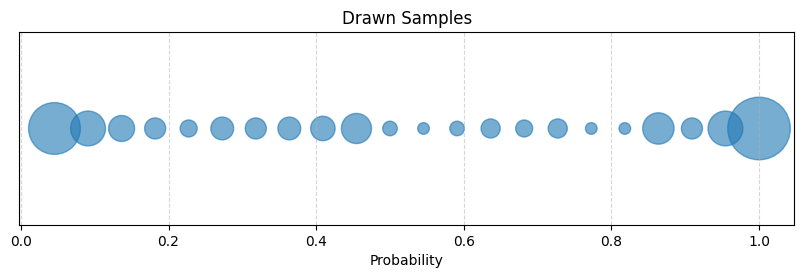

In [458]:
low_probs = [x["drawn_prob"] for x in low_samples]
high_probs = [x["drawn_prob"] for x in high_samples]
all_probs = low_probs + high_probs

counts = Counter(all_probs)

x_vals = sorted(counts.keys())
freqs = [counts[x] for x in x_vals]

y_vals = [0] * len(x_vals)

sizes = [30 + 40 * f for f in freqs]

plt.figure(figsize=(10, 2.5))
plt.scatter(x_vals, y_vals, s=sizes, alpha=0.6)

plt.yticks([])
plt.ylim(-0.1, 0.1)
plt.xlabel("Probability")
plt.title("Drawn Samples")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)

plt.savefig(f"samples/{dataset}_sample_plot.png")
plt.show()

In [459]:
# Alle Kandidaten-Wahrscheinlichkeiten sammeln
low_all_probs = [x["drawn_prob"] for x in low_candidates]
high_all_probs = [x["drawn_prob"] for x in high_candidates]
all_probs = low_all_probs + high_all_probs

# Optional: runden (empfohlen wegen Float-Problemen)
ROUND_DIGITS = 5
all_probs = [round(p, ROUND_DIGITS) for p in all_probs]

# Counter erstellen
counts = Counter(all_probs)

# In normales Dict umwandeln (JSON-kompatibel)
counts_dict = {str(k): v for k, v in counts.items()}
counts_dict = dict(sorted(counts_dict.items(), key=lambda x: float(x[0])))

# Speichern
output_path = f"samples/{dataset}_probability_counts.json"

with open(output_path, "w") as f:
    json.dump(counts_dict, f, indent=2)

print(f"Gespeichert unter: {output_path}")

Gespeichert unter: samples/COCO_probability_counts.json
